<a href="https://colab.research.google.com/github/penmalik/House-Price-Prediction-Analysis/blob/main/notebook/house_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HOUSE PRICE PREDICTION ANALYSIS WITH MULTIPLE LINEAR REGRESSION

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
# read the dataset in
df = pd.read_csv('../data/Housing.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Checking the uniqueness of each datapoint entry in the column, and find if a pattern exist in the dataset to help the model with more options to pick from

convert the (yes, no) into (1,0)

In [ ]:
for col in cols_unique:
  df[col] = df[col].map({'yes':1, 'no':0})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    int64 
 6   guestroom         545 non-null    int64 
 7   basement          545 non-null    int64 
 8   hotwaterheating   545 non-null    int64 
 9   airconditioning   545 non-null    int64 
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    int64 
 12  furnishingstatus  545 non-null    object
dtypes: int64(12), object(1)
memory usage: 55.5+ KB


In [ ]:
df['furnishingstatus'].value_counts()

,count
furnishingstatus,
semi-furnished,227
unfurnished,178
furnished,140


In [ ]:
df_encoded = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
df_encoded.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'],
      dtype='object')

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    b

In [ ]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [ ]:
cols_unique = ['furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

for col in cols_unique:
  print(col, df_encoded[col].unique())

df_encoded[cols_unique] = df_encoded[cols_unique].astype(int)

furnishingstatus_semi-furnished [False  True]
furnishingstatus_unfurnished [False  True]


In [ ]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


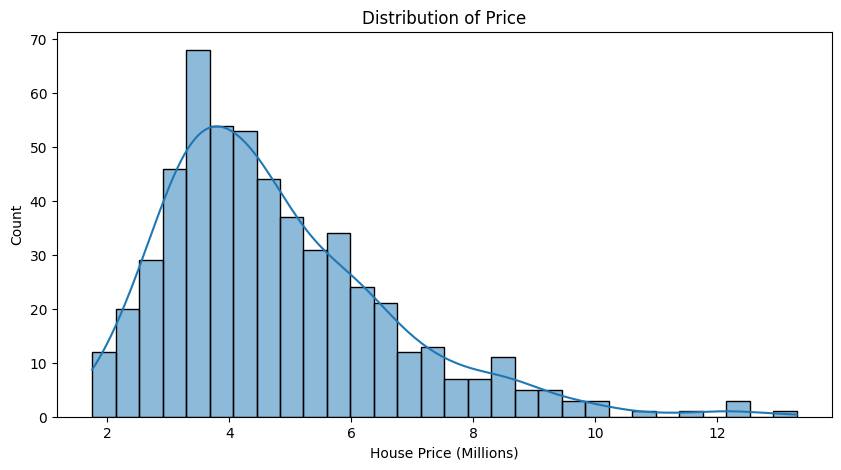

In [ ]:
# Histogram for House price
plt.figure(figsize=(10,5))
ax = sns.histplot(data=df, x=df['price']/1e6, bins=30, kde=True)
ax.set(title='Distribution of Price', xlabel='House Price (Millions)', ylabel='Count')
plt.show()

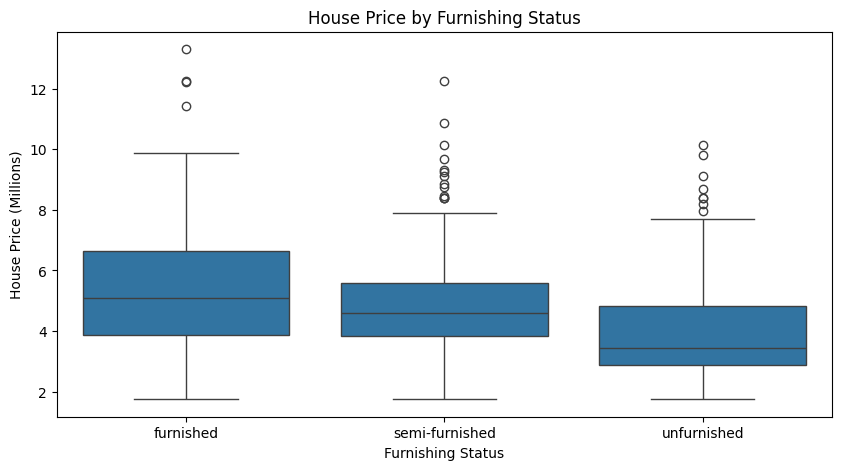

In [ ]:
# Furnishing Status vs House Price
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, x='furnishingstatus', y=df['price']/1e6)
ax.set(
    title='House Price by Furnishing Status',
    xlabel='Furnishing Status',
    ylabel='House Price (Millions)'
)
plt.show()

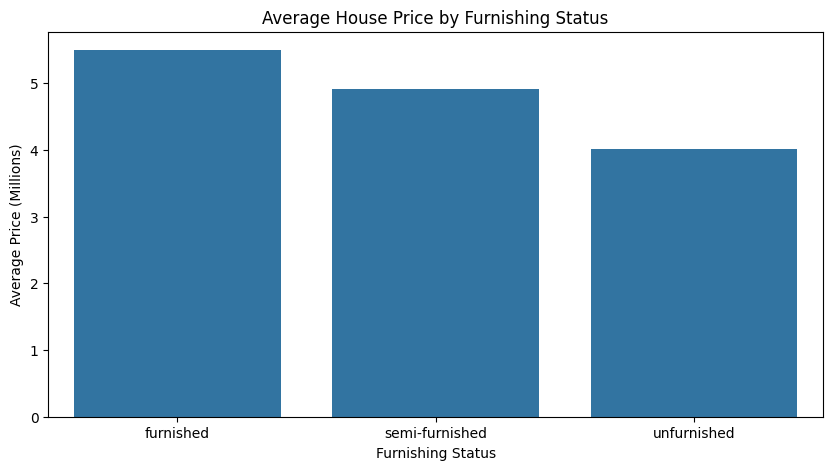

In [ ]:
# average price per category
avg_price = df.groupby('furnishingstatus')['price'].mean()/1e6
plt.figure(figsize=(10,5))
ax = sns.barplot(x=avg_price.index, y=avg_price.values)
ax.set(
    title='Average House Price by Furnishing Status',
    xlabel='Furnishing Status',
    ylabel='Average Price (Millions)'
)
plt.show()

SPLITTING THE DATA INTO TRAINING AND TEST SET

In [ ]:
# splitting data into training and test set

# multiple features
x = df_encoded.drop(columns=['price'])

# target variable
y = df['price']

# splitting the data into 80% training set and 20% test set
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Coefficient of the slope
coeffients = pd.DataFrame({
    'Features': x_train.columns,
    'Coeffient': model.coef_
})

# intercept
intercept = model.intercept_

display(coeffients)
print(f"Intercept => {intercept}")


,Features,Coeffient
0,area,2.359688e+02
1,bedrooms,7.677870e+04
2,bathrooms,1.094445e+06
3,stories,4.074766e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
6,basement,3.902512e+05
7,hotwaterheating,6.846499e+05
8,airconditioning,7.914267e+05
9,parking,2.248419e+05


Intercept => 260032.35760741122


In [ ]:
y_pred = model.predict(x_train)
print(y_pred)

[ 7109165.83869915  6882951.80434333  4815249.78634875  3990061.64537981
  3238924.34106255  4213259.45560891  3262521.22151669  2776422.43321996
  2329025.57980947  3653860.17702972  4084008.3526849   3686745.82238177
  4686517.16289528  3873464.37706931  4190240.83409353  5869519.40313554
  2431733.1569103   5789740.18200833  3330477.18628315  7871347.1127676
  6464175.05153338  3348710.98229962  5066745.68311879  6829041.62324658
  6441622.72524019  3215327.46060841  2359612.68424143  3177203.1918561
  5577561.1214436   3119493.38199004  4101305.3259745   2612119.22569566
  3901239.29674703  5228986.06476602  4122403.48334851  4005975.25747496
  2429223.48158114  6896328.29436496  5159484.34408525  6662050.04903446
  6939841.61654545  5455918.56569499  4382276.61245578  3950285.29106801
  3778024.21928121  3318897.97407654  7075245.51564247  7975008.19676279
  4037996.59102695  7033627.71592742  3658707.03856111  3874926.73483994
  6787030.2732729   5214207.63610125  5046219.3179053

In [ ]:
result_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_pred
})
# to avoid the Predicted values being display in scientific notation
result_df['Predicted'] = result_df['Predicted'].round(0).astype(int)
display(result_df.head())

,Actual,Predicted
46,7525000,7109166
93,6300000,6882952
335,3920000,4815250
412,3430000,3990062
471,3010000,3238924


In [ ]:
y_pred_test = model.predict(x_test)

In [ ]:
test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test
})

test_df['Predicted'] = test_df['Predicted'].round(0).astype(int)
display(test_df.head())

,Actual,Predicted
316,4060000,5164654
77,6650000,7224722
360,3710000,3109863
90,6440000,4612075
493,2800000,3294646


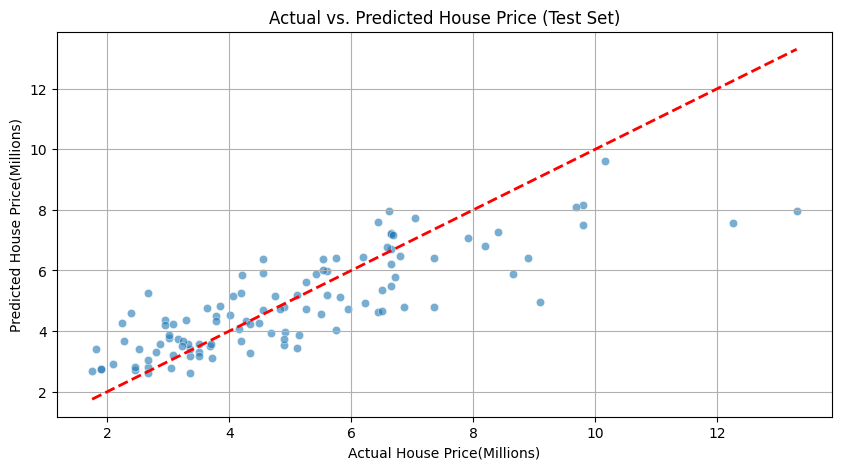

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.scatterplot(x=y_test/1e6, y=y_pred_test/1e6, alpha=0.6)
plt.plot([y_test.min()/1e6, y_test.max()/1e6], [y_test.min()/1e6, y_test.max()/1e6], 'r--', lw=2)
ax.set(title='Actual vs. Predicted House Price (Test Set)', xlabel='Actual House Price(Millions)', ylabel='Predicted House Price(Millions)')
plt.grid(True)
plt.show()

CHECKING HOW WELL MY MODEL WORKS

In [ ]:
from sklearn.metrics import mean_absolute_error

MAE = mean_absolute_error(y_test, y_pred_test)
MAE = round(MAE, 2)
print(MAE)

970043.4


In [ ]:
average_house_price = df['price'].mean()
MAE_avg = (MAE / average_house_price) * 100
print(round(MAE_avg, 2))

20.35


This tells us that, on average, our model predicts house prices within 21% of the actual price.


In [ ]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, y_pred)
r2_test = r2_score(y_test, y_pred_test)

print(f"R2_TRAIN -> {round(r2_train, 2)}")
print(f"R2_TEST -> {round(r2_test, 2)}")

R2_TRAIN -> 0.69
R2_TEST -> 0.65


**Interpretation:**

*   **0.0 - 0.3:** Very low or no linear relationship.
*   **0.3 - 0.5:** Weak linear relationship.
*   **0.5 - 0.7:** Moderate linear relationship.
*   **0.7 - 1.0:** Strong linear relationship.

In [ ]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})

importance['Coefficient'] = importance['Coefficient'].round(0).astype(int)

importance = importance.sort_values(by='Coefficient', ascending=False)

display(importance)

,Feature,Coefficient
2,bathrooms,1094445
8,airconditioning,791427
7,hotwaterheating,684650
10,prefarea,629891
3,stories,407477
6,basement,390251
4,mainroad,367920
5,guestroom,231610
9,parking,224842
1,bedrooms,76779


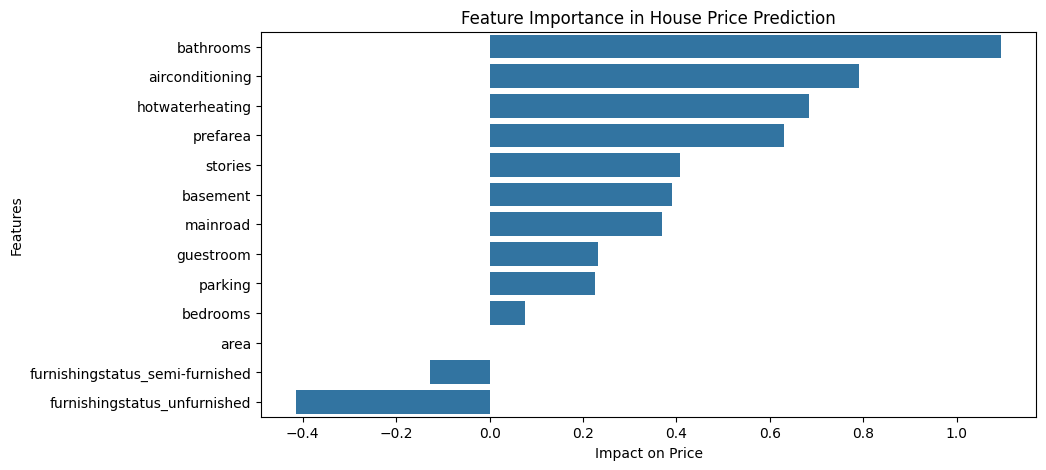

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(data=importance, x=importance['Coefficient']/1e6, y='Feature')
ax.set(title='Feature Importance in House Price Prediction', xlabel='Impact on Price', ylabel='Features')
plt.show()

**RESIDUALS** HELPS TO SHOW HOW WRONG THE MODEL IS AND WHETHER THE ERRORS ARE RANDOM.

Residuals = Actual − Predicted

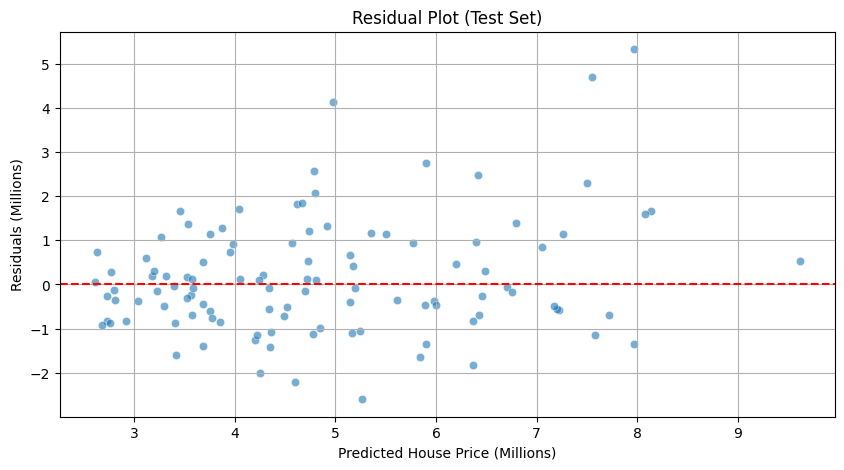

In [ ]:
residuals = y_test - y_pred_test

plt.figure(figsize=(10,5))

ax = sns.scatterplot(x=y_pred_test/1e6, y=residuals/1e6, alpha=0.6)

plt.axhline(0, color='red', linestyle='--')

ax.set(
    title='Residual Plot (Test Set)',
    xlabel='Predicted House Price (Millions)',
    ylabel='Residuals (Millions)'
)

plt.grid(True)
plt.show()

**Meaning:**

* Model errors are random
* Model assumptions are valid